# 비선형 데이터 해결 방법
### 1. 다항 차원 추가

c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


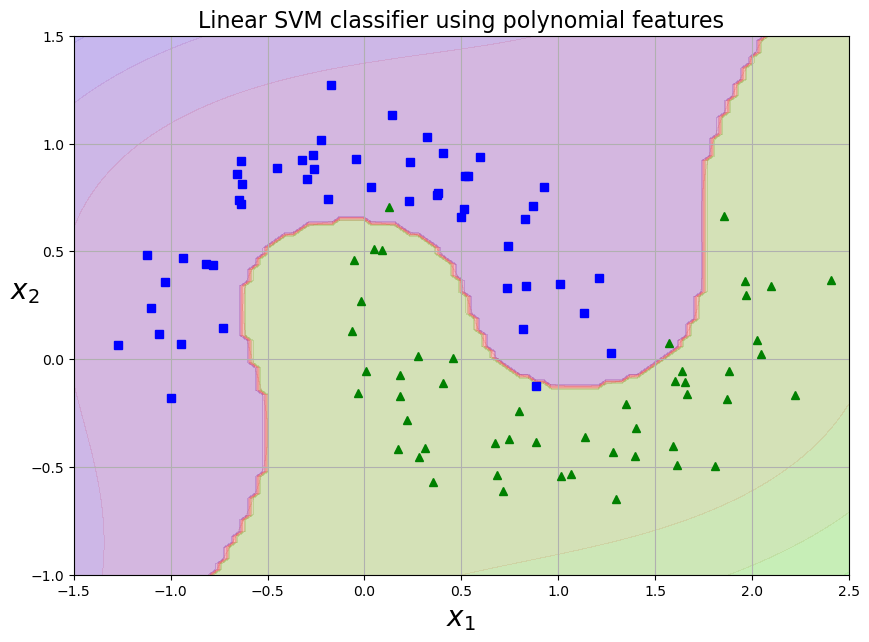

In [10]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt     # 시각화

# 데이터 생성
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# 모델 학습
poly_svm_clf = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3)),
    ("scaler", StandardScaler()),
    ("svm_clf", LinearSVC(C=10, loss="hinge"))
])
poly_svm_clf.fit(X,y)

# 시각화 함수 정의
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_grid = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X_grid).reshape(x0.shape)
    y_decision = clf.decision_function(X_grid).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs") # 클래스 0: 파란 사각형
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^") # 클래스 1: 녹색 삼각형
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

# 그래프 출력
plt.figure(figsize=(10, 7))
plot_predictions(poly_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])

plt.title("Linear SVM classifier using polynomial features", fontsize=16)
plt.show()

### 2. 커널 트릭 (Kernel Trick)

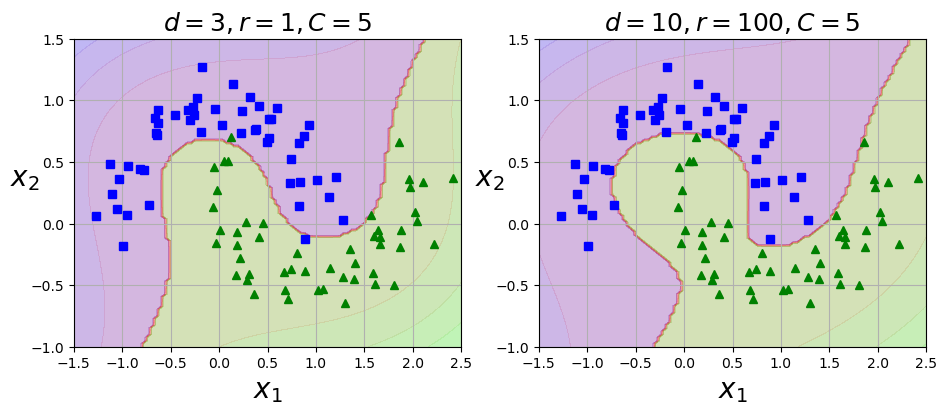

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. 데이터 생성 (moons 데이터셋)
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# 2. 시각화를 위한 보조 함수 정의
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X_new).reshape(x0.shape)
    y_decision = clf.decision_function(X_new).reshape(x0.shape)
    # 결정 경계 및 예측 영역 색칠
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs") # 클래스 0: 파란 사각형
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^") # 클래스 1: 초록 삼각형
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

# 3. 모델 설정 및 그래프 그리기 (두 가지 파라미터 비교)
# 모델 1: d=3, r=1, C=5
poly_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5))
])
poly_kernel_svm_clf.fit(X, y)

# 모델 2: d=10, r=100, C=5
poly100_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="poly", degree=10, coef0=100, C=5))
])
poly100_kernel_svm_clf.fit(X, y)

# 4. 그림 그리기 설정 (서브플롯 활용)
plt.figure(figsize=(11, 4))

# 왼쪽 그래프 (degree=3)
plt.subplot(121)
plot_predictions(poly_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title(r"$d=3, r=1, C=5$", fontsize=18)

# 오른쪽 그래프 (degree=10)
plt.subplot(122)
plot_predictions(poly100_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title(r"$d=10, r=100, C=5$", fontsize=18)

plt.show()

### 3. 가우스 RBF 커널

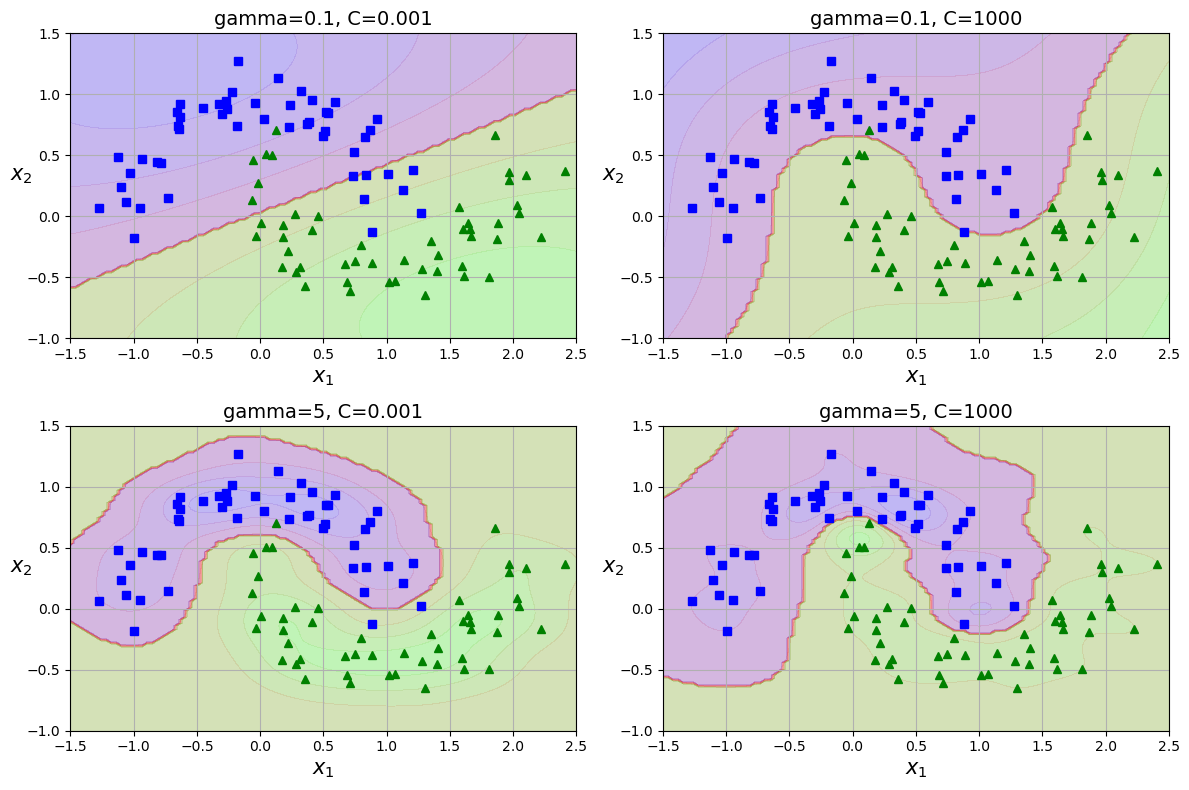

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. 시각화용 데이터 생성 (moons 데이터셋)
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# 2. 결정 경계 및 데이터를 그리기 위한 보조 함수 정의
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X_new).reshape(x0.shape)
    y_decision = clf.decision_function(X_new).reshape(x0.shape)
    # 배경 예측 영역 색칠
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    # 결정 경계 근처 등고선 색칠
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs") # 클래스 0: 파란 사각형
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^") # 클래스 1: 녹색 삼각형
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=15)
    plt.ylabel(r"$x_2$", fontsize=15, rotation=0)

# 3. 서로 다른 하이퍼파라미터 조합 설정
gamma_params = (0.1, 5)
C_params = (0.001, 1000)
hyperparams = []

for gamma in gamma_params:
    for C in C_params:
        hyperparams.append((gamma, C))

# 4. 그래프 그리기 시작
plt.figure(figsize=(12, 8))

for i, (gamma, C) in enumerate(hyperparams):
    # SVC 모델 파이프라인 구성 (스케일링 포함)
    rbf_kernel_svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(kernel="rbf", gamma=gamma, C=C))
    ])
    rbf_kernel_svm_clf.fit(X, y)

    # 2x2 서브플롯 설정
    plt.subplot(221 + i)
    plot_predictions(rbf_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
    plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
    plt.title(f"gamma={gamma}, C={C}", fontsize=14)

plt.tight_layout()
plt.show()